In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('dataset_sdn.csv')

#### I .Data Analysis

In [3]:
data.head()

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,1.010000e+11,3,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2.810000e+11,2,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0


In [4]:
data.Protocol.value_counts

<bound method IndexOpsMixin.value_counts of 0          UDP
1          UDP
2          UDP
3          UDP
4          UDP
          ... 
104340    ICMP
104341    ICMP
104342    ICMP
104343    ICMP
104344    ICMP
Name: Protocol, Length: 104345, dtype: object>

In [5]:
data.tail()

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
104340,5262,3,10.0.0.5,10.0.0.7,79,7742,81,842000000,8.184200e+10,5,...,0,0,ICMP,1,15209,12720,1,1.0,2.0,0
104341,5262,3,10.0.0.5,10.0.0.7,79,7742,81,842000000,8.184200e+10,5,...,0,0,ICMP,3,15099,14693,1,1.0,2.0,0
104342,5262,3,10.0.0.11,10.0.0.5,31,3038,31,805000000,3.180500e+10,5,...,1,0,ICMP,2,3409,3731,0,0.0,0.0,0
104343,5262,3,10.0.0.11,10.0.0.5,31,3038,31,805000000,3.180500e+10,5,...,1,0,ICMP,1,15209,12720,1,1.0,2.0,0
104344,5262,3,10.0.0.11,10.0.0.5,31,3038,31,805000000,3.180500e+10,5,...,1,0,ICMP,3,15099,14693,1,1.0,2.0,0


In [6]:
data.shape

(104345, 23)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104345 entries, 0 to 104344
Data columns (total 23 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   dt           104345 non-null  int64  
 1   switch       104345 non-null  int64  
 2   src          104345 non-null  object 
 3   dst          104345 non-null  object 
 4   pktcount     104345 non-null  int64  
 5   bytecount    104345 non-null  int64  
 6   dur          104345 non-null  int64  
 7   dur_nsec     104345 non-null  int64  
 8   tot_dur      104345 non-null  float64
 9   flows        104345 non-null  int64  
 10  packetins    104345 non-null  int64  
 11  pktperflow   104345 non-null  int64  
 12  byteperflow  104345 non-null  int64  
 13  pktrate      104345 non-null  int64  
 14  Pairflow     104345 non-null  int64  
 15  Protocol     104345 non-null  object 
 16  port_no      104345 non-null  int64  
 17  tx_bytes     104345 non-null  int64  
 18  rx_bytes     104345 non-

In [8]:
##### Here we see that the label contains boolean values: 0 - Benign, 1-Maliciuous 
data.label.unique()

array([0, 1], dtype=int64)

In [9]:
data.label.value_counts()

label
0    63561
1    40784
Name: count, dtype: int64

In [10]:
data.describe()

,dt,switch,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,pktperflow,byteperflow,pktrate,Pairflow,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
count,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,1.043450e+05,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,1.043450e+05,104345.000000,103839.000000,103839.000000,104345.000000
mean,17927.514169,4.214260,52860.954746,3.818660e+07,321.497398,4.613880e+08,3.218865e+11,5.654234,5200.383468,6381.715291,4.716150e+06,212.210676,0.600987,2.331094,9.325264e+07,9.328039e+07,998.899756,1003.811420,2007.578742,0.390857
std,11977.642655,1.956327,52023.241460,4.877748e+07,283.518232,2.770019e+08,2.834029e+11,2.950036,5257.001450,7404.777808,7.560116e+06,246.855123,0.489698,1.084333,1.519380e+08,1.330004e+08,2423.471618,2054.887034,3144.437173,0.487945
min,2488.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,2.000000,4.000000,-130933.000000,-1.464426e+08,-4365.000000,0.000000,1.000000,2.527000e+03,8.560000e+02,0.000000,0.000000,0.000000,0.000000
25%,7098.000000,3.000000,808.000000,7.957600e+04,127.000000,2.340000e+08,1.270000e+11,3.000000,1943.000000,29.000000,2.842000e+03,0.000000,0.000000,1.000000,4.743000e+03,3.539000e+03,0.000000,0.000000,0.000000,0.000000
50%,11905.000000,4.000000,42828.000000,6.471930e+06,251.000000,4.180000e+08,2.520000e+11,5.000000,3024.000000,8305.000000,5.521680e+05,276.000000,1.000000,2.000000,4.219610e+06,1.338339e+07,0.000000,0.000000,4.000000,0.000000
75%,29952.000000,5.000000,94796.000000,7.620354e+07,412.000000,7.030000e+08,4.130000e+11,7.000000,7462.000000,10017.000000,9.728112e+06,333.000000,1.000000,3.000000,1.356398e+08,1.439277e+08,251.000000,557.000000,3838.000000,1.000000
max,42935.000000,10.000000,260006.000000,1.471280e+08,1881.000000,9.990000e+08,1.880000e+12,17.000000,25224.000000,19190.000000,1.495387e+07,639.000000,1.000000,5.000000,1.269982e+09,9.905962e+08,20580.000000,16577.000000,20580.000000,1.000000


In [11]:
data.isnull().sum()

dt               0
switch           0
src              0
dst              0
pktcount         0
bytecount        0
dur              0
dur_nsec         0
tot_dur          0
flows            0
packetins        0
pktperflow       0
byteperflow      0
pktrate          0
Pairflow         0
Protocol         0
port_no          0
tx_bytes         0
rx_bytes         0
tx_kbps          0
rx_kbps        506
tot_kbps       506
label            0
dtype: int64

In [12]:
data.dropna(inplace=True)

In [13]:
data.isnull().sum()

dt             0
switch         0
src            0
dst            0
pktcount       0
bytecount      0
dur            0
dur_nsec       0
tot_dur        0
flows          0
packetins      0
pktperflow     0
byteperflow    0
pktrate        0
Pairflow       0
Protocol       0
port_no        0
tx_bytes       0
rx_bytes       0
tx_kbps        0
rx_kbps        0
tot_kbps       0
label          0
dtype: int64

In [14]:
data.shape

(103839, 23)

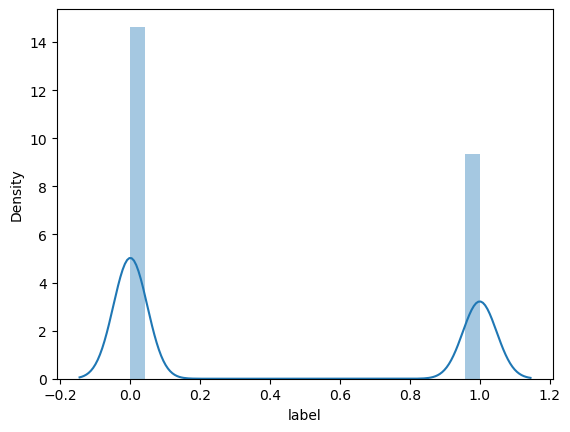

In [15]:

sns.distplot(data.label)
plt.show()

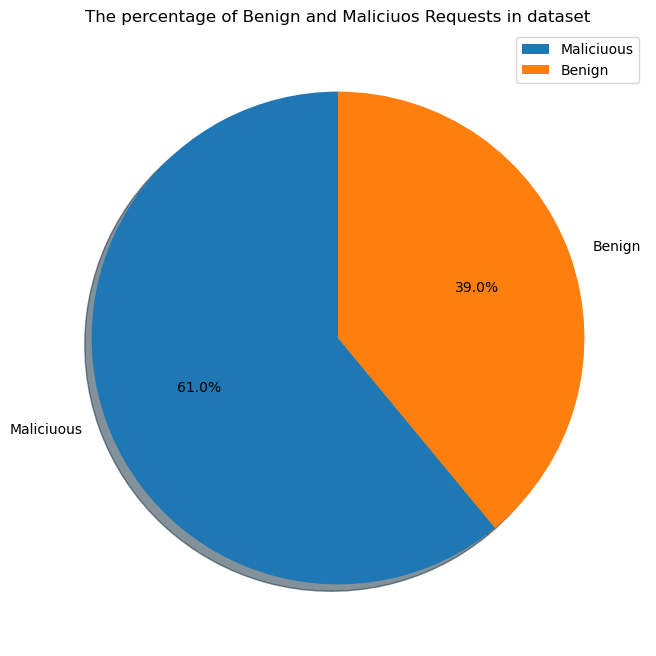

In [16]:
labels = ["Maliciuous",'Benign']
sizes = [dict(data.label.value_counts())[0], dict(data.label.value_counts())[1]]
plt.figure(figsize = (13,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.legend(["Maliciuous", "Benign"])
plt.title('The percentage of Benign and Maliciuos Requests in dataset')
plt.show()

In [17]:
data.describe()

,dt,switch,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,pktperflow,byteperflow,pktrate,Pairflow,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
count,103839.000000,103839.000000,103839.000000,1.038390e+05,103839.000000,1.038390e+05,1.038390e+05,103839.000000,103839.000000,103839.000000,1.038390e+05,103839.000000,103839.000000,103839.000000,1.038390e+05,1.038390e+05,103839.000000,103839.000000,103839.000000,103839.000000
mean,17999.454165,4.214496,52781.703165,3.801729e+07,322.126118,4.613734e+08,3.225151e+11,5.666339,5196.261308,6365.870588,4.689472e+06,211.682248,0.603916,2.337580,9.370704e+07,9.373492e+07,1003.767322,1003.811420,2007.578742,0.390065
std,11962.227566,1.956320,52061.409178,4.874544e+07,283.926141,2.771020e+08,2.838104e+11,2.951013,5266.631950,7413.263909,7.562023e+06,247.138265,0.489085,1.082973,1.521679e+08,1.331642e+08,2428.363391,2054.887034,3144.437173,0.487767
min,2488.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,2.000000,4.000000,-130933.000000,-1.464426e+08,-4365.000000,0.000000,1.000000,2.527000e+03,8.560000e+02,0.000000,0.000000,0.000000,0.000000
25%,7128.000000,3.000000,801.000000,7.928200e+04,128.000000,2.330000e+08,1.280000e+11,3.000000,1943.000000,29.000000,2.842000e+03,0.000000,0.000000,1.000000,4.799000e+03,3.539000e+03,0.000000,0.000000,0.000000,0.000000
50%,11965.000000,4.000000,42557.000000,6.409692e+06,252.000000,4.180000e+08,2.520000e+11,5.000000,3024.000000,8304.000000,5.447360e+05,276.000000,1.000000,2.000000,4.552643e+06,1.401134e+07,0.000000,0.000000,4.000000,0.000000
75%,29982.000000,5.000000,94683.000000,7.597222e+07,413.000000,7.040000e+08,4.130000e+11,7.000000,7385.000000,10004.000000,9.727070e+06,333.000000,1.000000,3.000000,1.356509e+08,1.439286e+08,255.000000,557.000000,3838.000000,1.000000
max,42935.000000,10.000000,260006.000000,1.471280e+08,1881.000000,9.990000e+08,1.880000e+12,17.000000,25224.000000,19190.000000,1.495387e+07,639.000000,1.000000,5.000000,1.269982e+09,9.905962e+08,20580.000000,16577.000000,20580.000000,1.000000


In [18]:
#### Let's support which columns NUMERIC and which is OBJECT

numeric_df = data.select_dtypes(include=['int64', 'float64'])
object_df = data.select_dtypes(include=['object'])
numeric_cols = numeric_df.columns
object_cols = object_df.columns
print('Numeric Columns: ')
print(numeric_cols, '\n')
print('Object Columns: ')
print(object_cols, '\n')
print('Number of Numeric Features: ', len(numeric_cols))
print('Number of Object Features: ', len(object_cols))

Numeric Columns: 
Index(['dt', 'switch', 'pktcount', 'bytecount', 'dur', 'dur_nsec', 'tot_dur',
       'flows', 'packetins', 'pktperflow', 'byteperflow', 'pktrate',
       'Pairflow', 'port_no', 'tx_bytes', 'rx_bytes', 'tx_kbps', 'rx_kbps',
       'tot_kbps', 'label'],
      dtype='object') 

Object Columns: 
Index(['src', 'dst', 'Protocol'], dtype='object') 

Number of Numeric Features:  20
Number of Object Features:  3


In [19]:
object_df.head()

,src,dst,Protocol
0,10.0.0.1,10.0.0.8,UDP
1,10.0.0.1,10.0.0.8,UDP
2,10.0.0.2,10.0.0.8,UDP
3,10.0.0.2,10.0.0.8,UDP
4,10.0.0.2,10.0.0.8,UDP


Text(0.5, 1.0, 'Number of all reqests')

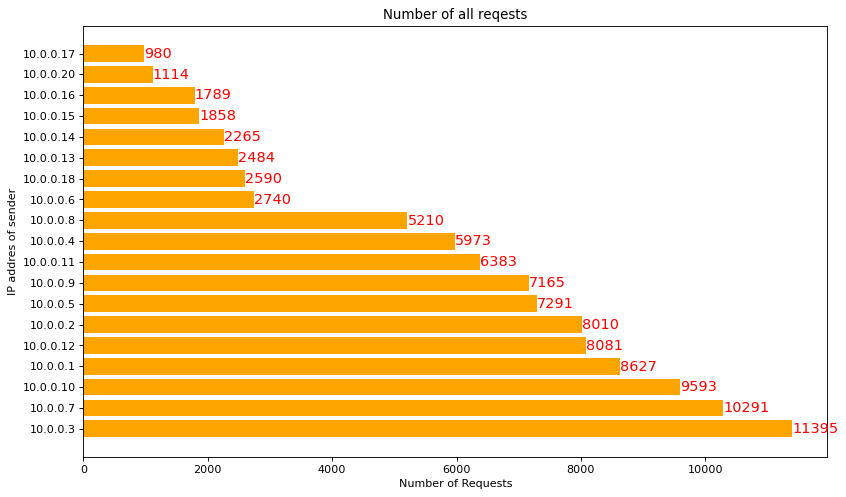

In [20]:
#### Let's look at Oblect columns (Source Destination Protocol)

figure(figsize=(12, 7), dpi=80)
plt.barh(list(dict(data.src.value_counts()).keys()), dict(data.src.value_counts()).values(), color='orange')

for idx, val in enumerate(dict(data.src.value_counts()).values()):
    plt.text(x = val, y = idx-0.2, s = str(val), color='r', size = 13)

plt.xlabel('Number of Requests')
plt.ylabel('IP addres of sender')
plt.title('Number of all reqests')

Text(0.5, 1.0, 'Number of Attack requests')

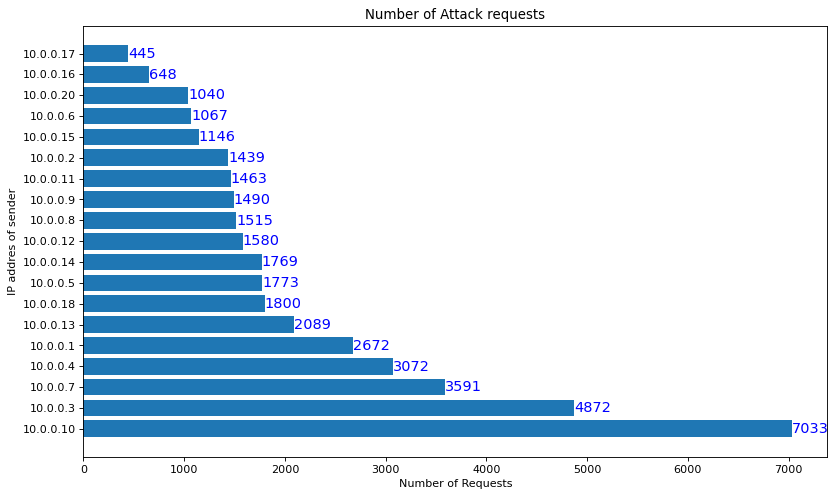

In [21]:
figure(figsize=(12, 7), dpi=80)
plt.barh(list(dict(data[data.label == 1].src.value_counts()).keys()), dict(data[data.label == 1].src.value_counts()).values())

for idx, val in enumerate(dict(data[data.label == 1].src.value_counts()).values()):
    plt.text(x = val, y = idx-0.2, s = str(val), color='b', size = 13)

plt.xlabel('Number of Requests')
plt.ylabel('IP addres of sender')
plt.title('Number of Attack requests')

Text(0.5, 1.0, 'Number of requests from different IP adress')

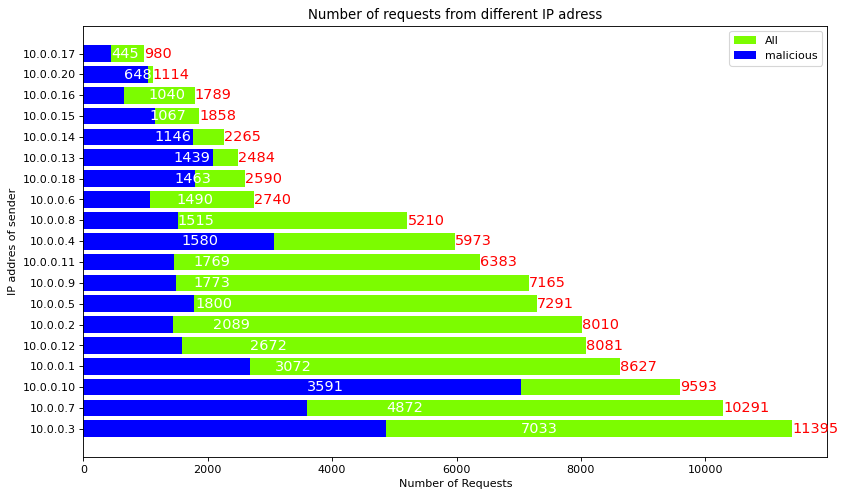

In [22]:
figure(figsize=(12, 7), dpi=80)
plt.barh(list(dict(data.src.value_counts()).keys()), dict(data.src.value_counts()).values(), color='lawngreen')
plt.barh(list(dict(data[data.label == 1].src.value_counts()).keys()), dict(data[data.label == 1].src.value_counts()).values(), color='blue')

for idx, val in enumerate(dict(data.src.value_counts()).values()):
    plt.text(x = val, y = idx-0.2, s = str(val), color='r', size = 13)

for idx, val in enumerate(dict(data[data.label == 1].src.value_counts()).values()):
    plt.text(x = val, y = idx-0.2, s = str(val), color='w', size = 13)


plt.xlabel('Number of Requests')
plt.ylabel('IP addres of sender')
plt.legend(['All','malicious'])
plt.title('Number of requests from different IP adress')

Text(0.5, 1.0, 'The number of requests from different protocols')

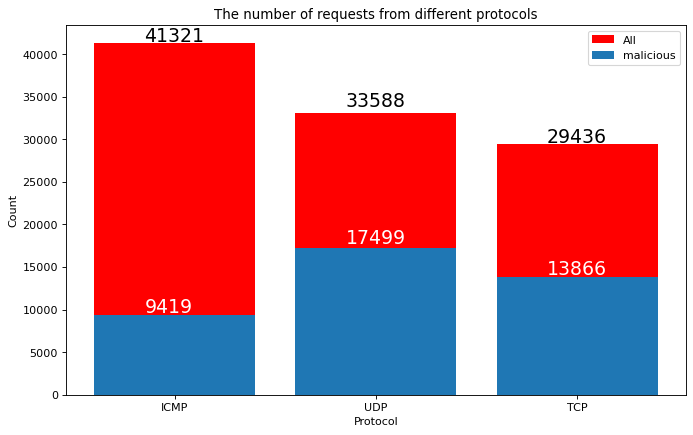

In [23]:
figure(figsize=(10, 6), dpi=80)
plt.bar(list(dict(data.Protocol.value_counts()).keys()), dict(data.Protocol.value_counts()).values(), color='r')
plt.bar(list(dict(data[data.label == 1].Protocol.value_counts()).keys()), dict(data[data.label == 1].Protocol.value_counts()).values())

plt.text(x = 0 - 0.15, y = 41321 + 200, s = str(41321), color='black', size=17)
plt.text(x = 1 - 0.15, y = 33588 + 200, s = str(33588), color='black', size=17)
plt.text(x = 2 - 0.15, y = 29436 + 200, s = str(29436), color='black', size=17)

plt.text(x = 0 - 0.15, y = 9419 + 200, s = str(9419), color='w', size=17)
plt.text(x = 1 - 0.15, y = 17499 + 200, s = str(17499), color='w', size=17)
plt.text(x = 2 - 0.15, y = 13866 + 200, s = str(13866), color='w', size=17)

plt.xlabel('Protocol')
plt.ylabel('Count')
plt.legend(['All', 'malicious'])
plt.title('The number of requests from different protocols')

In [24]:
df = data.copy()

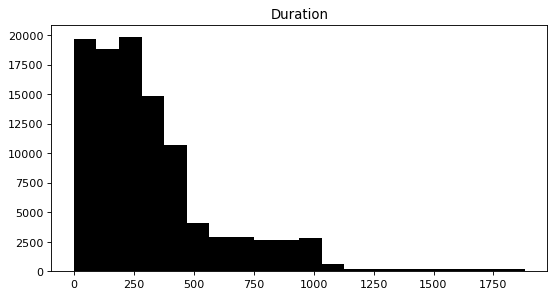

In [25]:
figure(figsize=(8, 4), dpi=80)
plt.hist(df.dur, bins=20, color='k')
plt.title('Duration')
plt.show()

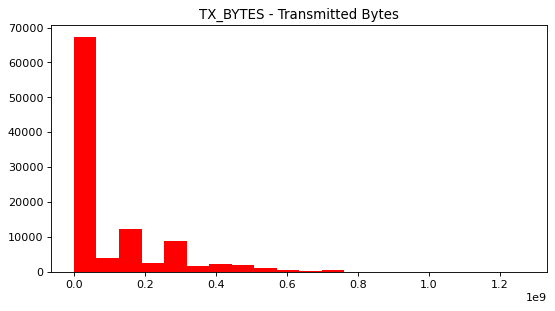

In [26]:
figure(figsize=(8, 4), dpi=80)
plt.hist(df.tx_bytes, bins=20, color='r')
plt.title('TX_BYTES - Transmitted Bytes')
plt.show()

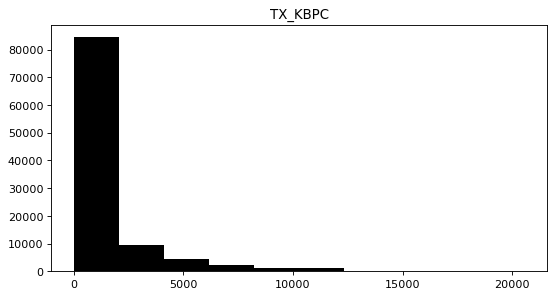

In [27]:
figure(figsize=(8, 4), dpi=80)
plt.hist(df.tx_kbps, bins=10, color='k')
plt.title('TX_KBPC')
plt.show()

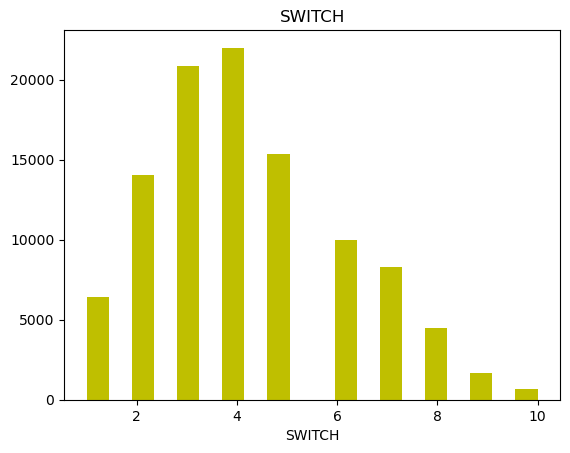

In [28]:
plt.hist(df.switch, bins=20, color='y')
plt.title('SWITCH')
plt.xlabel('SWITCH')
plt.show()

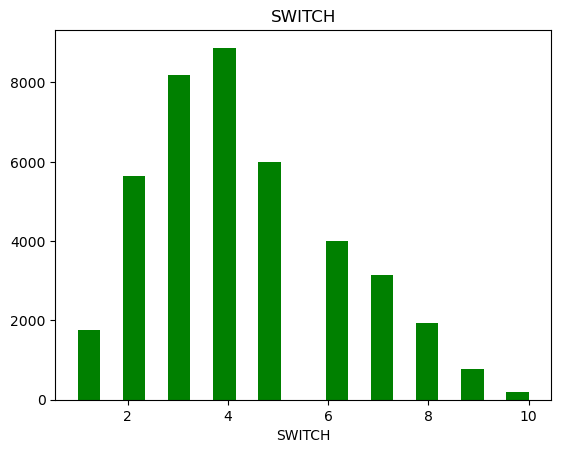

In [29]:
plt.hist(df[df['label'] == 1].switch, bins=20, color='g')
plt.title('SWITCH')
plt.xlabel('SWITCH')
plt.show()

In [30]:
data

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,1.010000e+11,3,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2.810000e+11,2,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104340,5262,3,10.0.0.5,10.0.0.7,79,7742,81,842000000,8.184200e+10,5,...,0,0,ICMP,1,15209,12720,1,1.0,2.0,0
104341,5262,3,10.0.0.5,10.0.0.7,79,7742,81,842000000,8.184200e+10,5,...,0,0,ICMP,3,15099,14693,1,1.0,2.0,0
104342,5262,3,10.0.0.11,10.0.0.5,31,3038,31,805000000,3.180500e+10,5,...,1,0,ICMP,2,3409,3731,0,0.0,0.0,0
104343,5262,3,10.0.0.11,10.0.0.5,31,3038,31,805000000,3.180500e+10,5,...,1,0,ICMP,1,15209,12720,1,1.0,2.0,0


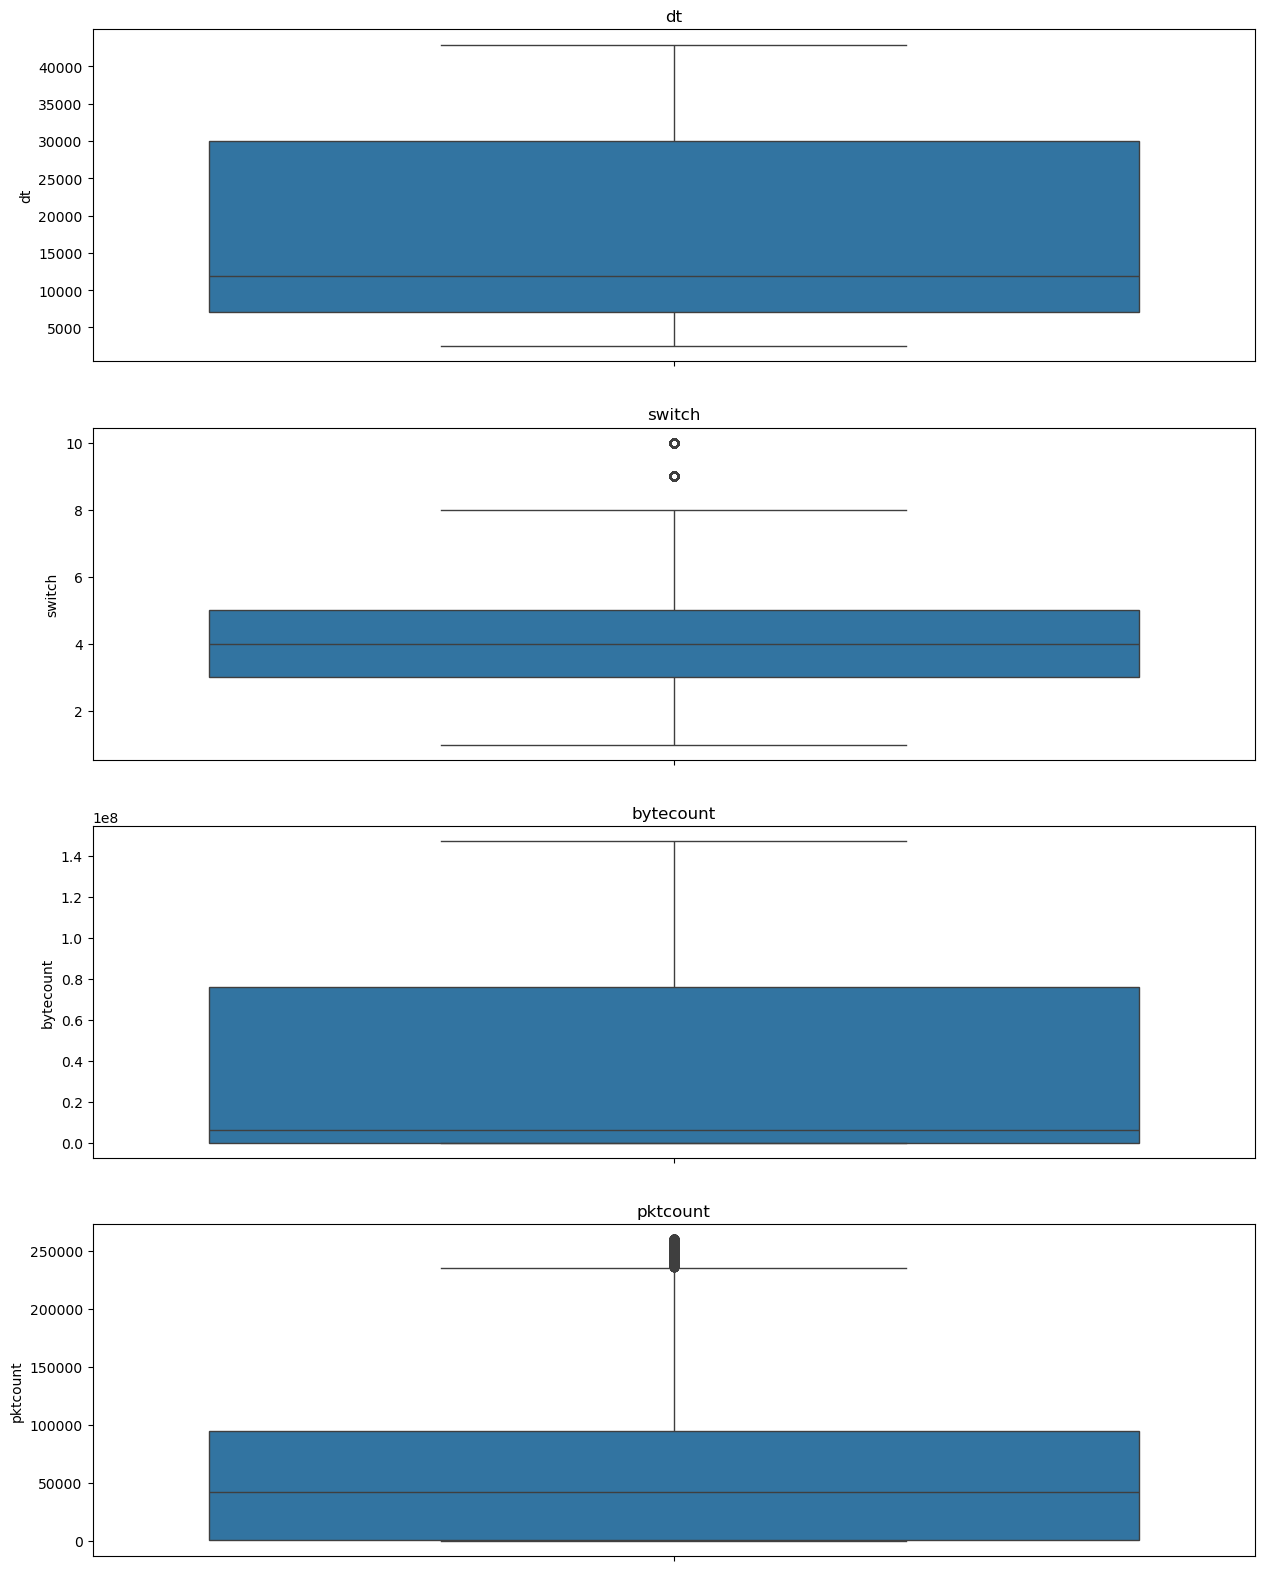

In [31]:
plt.figure(figsize = (15,25))

plt.subplot(5,1,1)
sns.boxplot(data['dt'] )
plt.title('dt')

plt.subplot(5,1,2)
sns.boxplot(data['switch'] )
plt.title('switch')

plt.subplot(5,1,3)
sns.boxplot(data['bytecount'])
plt.title('bytecount')

plt.subplot(5,1,4)
sns.boxplot(data['pktcount'])
plt.title('pktcount')



plt.show()

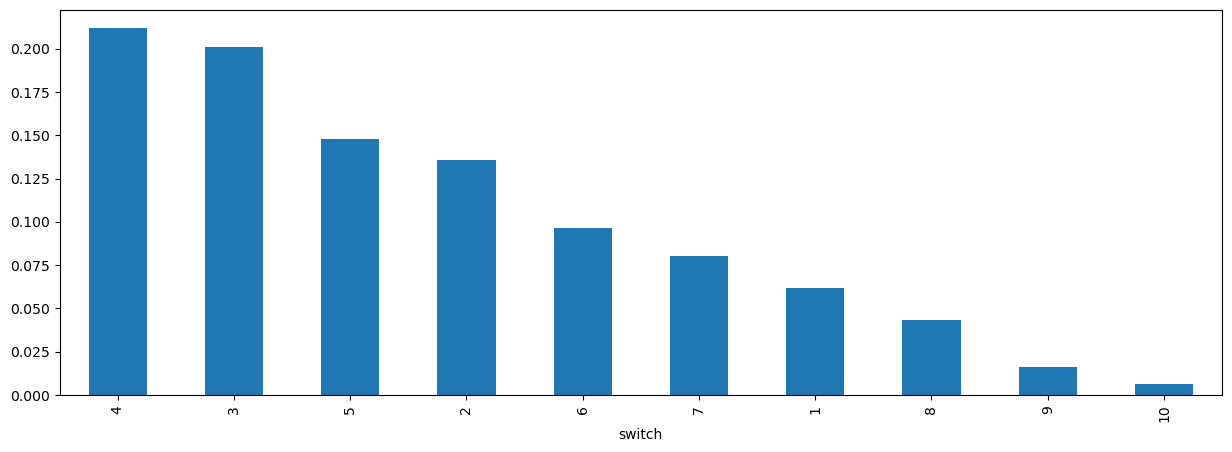

In [32]:
plt.figure(figsize = (15,5))
data['switch'].value_counts(normalize = True).head(10).plot.bar()
plt.show()

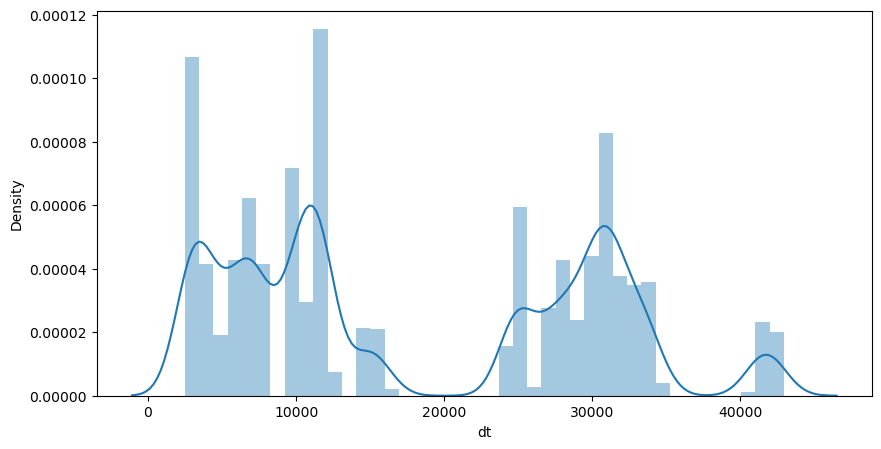

In [33]:
# lets plot distribution of all the variables
plt.figure(figsize = (10,5))
sns.distplot(data['dt'])
plt.show()

<Figure size 1000x800 with 0 Axes>

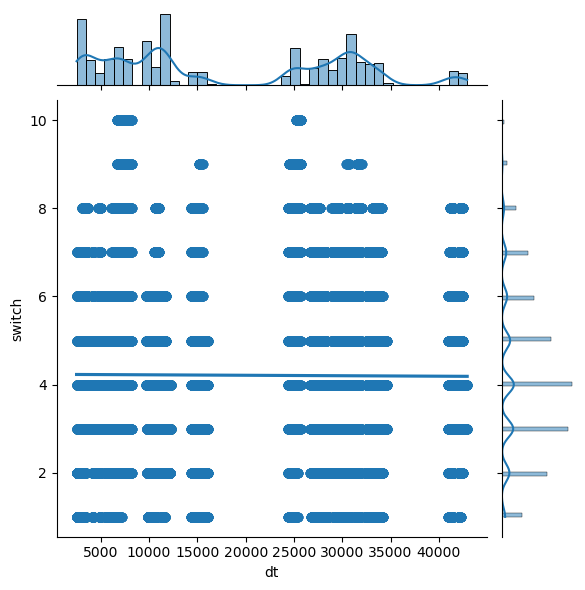

In [34]:
plt.figure(figsize = (10,8))
sns.jointplot(x = data['dt'] , y = data['switch'] , kind = 'reg')
plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder
labelencoder =  LabelEncoder()

In [36]:
data

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,1.010000e+11,3,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2.810000e+11,2,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104340,5262,3,10.0.0.5,10.0.0.7,79,7742,81,842000000,8.184200e+10,5,...,0,0,ICMP,1,15209,12720,1,1.0,2.0,0
104341,5262,3,10.0.0.5,10.0.0.7,79,7742,81,842000000,8.184200e+10,5,...,0,0,ICMP,3,15099,14693,1,1.0,2.0,0
104342,5262,3,10.0.0.11,10.0.0.5,31,3038,31,805000000,3.180500e+10,5,...,1,0,ICMP,2,3409,3731,0,0.0,0.0,0
104343,5262,3,10.0.0.11,10.0.0.5,31,3038,31,805000000,3.180500e+10,5,...,1,0,ICMP,1,15209,12720,1,1.0,2.0,0


In [37]:
data=data.drop('packetins',axis=1)

In [38]:
data=data.drop('pktperflow',axis=1)

In [39]:
data=data.drop('byteperflow',axis=1)

In [40]:
data.Protocol.value_counts()

Protocol
ICMP    41321
UDP     33082
TCP     29436
Name: count, dtype: int64

In [41]:
from sklearn import preprocessing

# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()
#Encoding data
labelDict = {}
for feature in data:
    le = preprocessing.LabelEncoder()
    le.fit(data[feature])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    data[feature] = le.transform(data[feature])
    # Get labels
    labelKey = 'label_' + feature
    labelValue = [*le_name_mapping]
    labelDict[labelKey] =labelValue

for key, value in labelDict.items():
    print(key, value)



label_dt [2488, 2518, 2548, 2578, 2608, 2638, 2649, 2668, 2679, 2709, 2740, 2741, 2769, 2799, 2829, 2859, 2889, 2919, 2949, 2979, 3009, 3069, 3099, 3129, 3159, 3189, 3219, 3249, 3279, 3309, 3339, 3369, 3399, 3429, 3459, 3489, 3519, 3549, 3579, 3609, 3639, 3669, 3699, 3729, 3789, 3819, 3849, 3879, 3909, 3939, 3969, 3999, 4007, 4029, 4037, 4059, 4067, 4089, 4097, 4119, 4127, 4149, 4187, 4217, 4247, 4277, 4307, 4337, 4367, 4397, 4427, 4457, 4487, 4517, 4547, 4577, 4607, 4697, 4727, 4757, 4787, 4817, 4847, 4877, 4907, 4937, 4967, 4997, 5027, 5057, 5087, 5117, 5147, 5177, 5202, 5207, 5232, 5237, 5262, 5267, 5292, 5297, 5322, 5352, 5357, 5382, 5387, 5412, 5417, 5442, 5447, 5472, 5477, 5502, 5507, 5532, 5537, 5562, 5567, 5592, 5597, 5622, 5627, 5652, 5657, 5682, 5687, 5712, 5717, 5742, 5772, 5802, 5832, 5862, 5892, 5922, 5952, 5982, 6012, 6042, 6072, 6103, 6132, 6162, 6192, 6222, 6252, 6282, 6312, 6342, 6372, 6402, 6432, 6462, 6492, 6522, 6552, 6582, 6612, 6642, 6672, 6702, 6732, 6762, 6792, 

In [42]:
data

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,305,0,0,16,3176,6960,100,716,3447,1,302,0,2,2,8607,326,0,0,0,0
1,317,0,0,16,7844,8943,280,734,3627,0,302,0,2,3,222,265,0,0,0,0
2,305,0,10,16,5777,8052,200,744,3547,1,302,0,2,0,207,22,0,0,0,0
3,305,0,10,16,5777,8052,200,744,3547,1,302,0,2,1,161,50,0,0,0,0
4,305,0,10,16,5777,8052,200,744,3547,1,302,0,2,2,86,287,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104340,98,2,14,15,47,53,81,842,2882,3,29,0,0,0,1377,748,1,1,2,0
104341,98,2,14,15,47,53,81,842,2882,3,29,0,0,2,1376,779,1,1,2,0
104342,98,2,2,13,19,21,31,805,1125,3,30,0,0,1,85,299,0,0,0,0
104343,98,2,2,13,19,21,31,805,1125,3,30,0,0,0,1377,748,1,1,2,0


In [43]:
data=data.drop('tot_dur',axis=1)

In [44]:
data

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,flows,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,305,0,0,16,3176,6960,100,716,1,302,0,2,2,8607,326,0,0,0,0
1,317,0,0,16,7844,8943,280,734,0,302,0,2,3,222,265,0,0,0,0
2,305,0,10,16,5777,8052,200,744,1,302,0,2,0,207,22,0,0,0,0
3,305,0,10,16,5777,8052,200,744,1,302,0,2,1,161,50,0,0,0,0
4,305,0,10,16,5777,8052,200,744,1,302,0,2,2,86,287,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104340,98,2,14,15,47,53,81,842,3,29,0,0,0,1377,748,1,1,2,0
104341,98,2,14,15,47,53,81,842,3,29,0,0,2,1376,779,1,1,2,0
104342,98,2,2,13,19,21,31,805,3,30,0,0,1,85,299,0,0,0,0
104343,98,2,2,13,19,21,31,805,3,30,0,0,0,1377,748,1,1,2,0


In [45]:
X = data.drop(['dt','src','dst','label','Protocol','tot_kbps'], axis=1)
y = data['label']

In [46]:
X.columns

Index(['switch', 'pktcount', 'bytecount', 'dur', 'dur_nsec', 'flows',
       'pktrate', 'Pairflow', 'port_no', 'tx_bytes', 'rx_bytes', 'tx_kbps',
       'rx_kbps'],
      dtype='object')

In [47]:
y

0         0
1         0
2         0
3         0
4         0
         ..
104340    0
104341    0
104342    0
104343    0
104344    0
Name: label, Length: 103839, dtype: int64

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3)

In [49]:
X_train

,switch,pktcount,bytecount,dur,dur_nsec,flows,pktrate,Pairflow,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps
98485,0,183,203,301,600,2,29,0,1,1717,5623,0,893
73094,1,7225,4633,211,946,5,388,1,3,9153,11197,304,1016
41436,6,1656,1287,60,205,2,212,1,0,3857,6404,150,1176
98940,1,4771,7581,241,406,5,203,1,3,10779,7208,1344,1
59027,5,439,468,589,356,3,30,1,2,7599,9875,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85995,4,2565,6743,79,46,3,284,1,3,11045,9209,121,1165
61161,3,0,0,0,93,3,29,1,0,1240,585,0,0
35964,2,6440,4067,164,108,7,440,1,0,4689,3520,0,0
25696,3,3595,7126,114,512,2,298,0,1,11438,467,1630,0


In [50]:
y_train

98485    0
73094    0
41436    1
98940    1
59027    0
        ..
85995    0
61161    0
35964    1
25696    0
19431    0
Name: label, Length: 72687, dtype: int64

In [51]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
model = RandomForestClassifier(n_estimators=10, random_state=42) 
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rf_acc = accuracy_score(y_test, y_pred)

print(mse)
print(rf_acc)


0.006131227529532614
0.9938687724704673


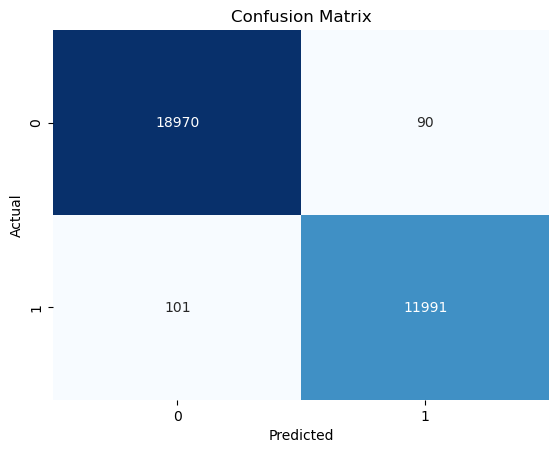

In [52]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19060
           1       0.99      0.99      0.99     12092

    accuracy                           0.99     31152
   macro avg       0.99      0.99      0.99     31152
weighted avg       0.99      0.99      0.99     31152



In [54]:

from sklearn.svm import SVC
model1 = SVC() 
model1.fit(X_train, y_train)

# Make predictions on the test data
y_predict = model.predict(X_test)
mse = mean_squared_error(y_test, y_predict)
svm_acc = accuracy_score(y_test, y_predict)
print(mse)
print(svm_acc)

0.006131227529532614
0.9938687724704673


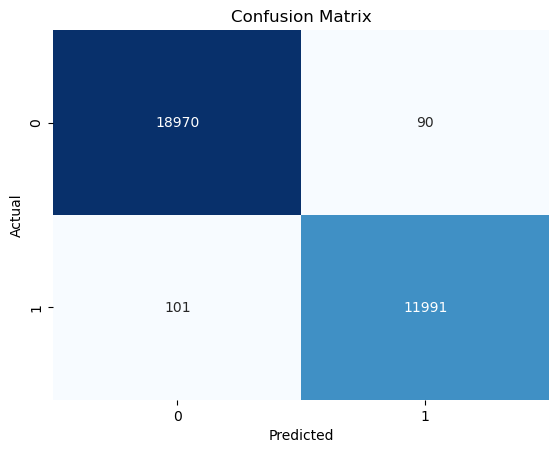

In [55]:
cm = confusion_matrix(y_test, y_predict)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [56]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19060
           1       0.99      0.99      0.99     12092

    accuracy                           0.99     31152
   macro avg       0.99      0.99      0.99     31152
weighted avg       0.99      0.99      0.99     31152



In [57]:

from sklearn.tree import DecisionTreeClassifier

regressor = DecisionTreeClassifier()  
regressor.fit(X_train, y_train)
y_pr= regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pr)
dt_acc=accuracy_score(y_test, y_pr)
print(mse)
print(dt_acc)



0.005521314843348742
0.9944786851566513


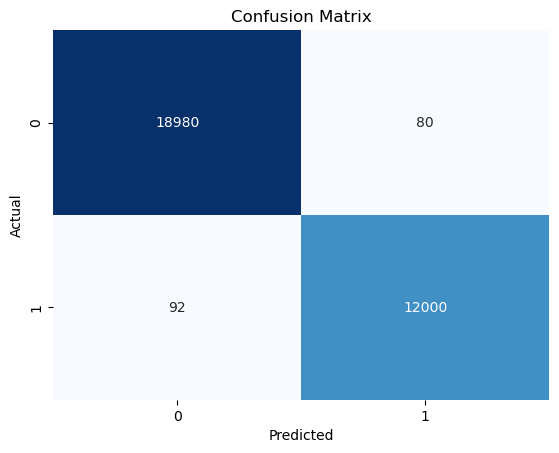

In [58]:
cm = confusion_matrix(y_test, y_pr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [59]:
print(classification_report(y_test, y_pr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19060
           1       0.99      0.99      0.99     12092

    accuracy                           0.99     31152
   macro avg       0.99      0.99      0.99     31152
weighted avg       0.99      0.99      0.99     31152



In [60]:
from sklearn.neighbors import KNeighborsClassifier
KN = KNeighborsClassifier()


In [61]:
KN.fit(X_train, y_train)

KNeighborsClassifier()

In [62]:
y_p= KN.predict(X_test)

In [63]:
mse = mean_squared_error(y_test, y_p)
kn_acc=accuracy_score(y_test, y_p)
print(mse)
print(kn_acc)

0.0734784283513097
0.9265215716486903


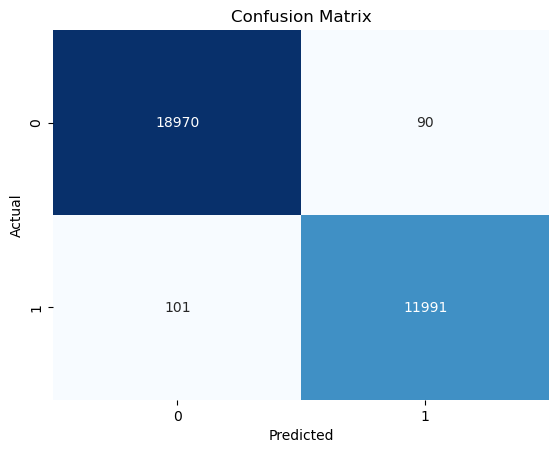

In [64]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
#print(confusion_matrix(y_test, y_p))

In [65]:
print(classification_report(y_test, y_p))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94     19060
           1       0.90      0.91      0.91     12092

    accuracy                           0.93     31152
   macro avg       0.92      0.92      0.92     31152
weighted avg       0.93      0.93      0.93     31152



In [66]:
from sklearn.ensemble import GradientBoostingClassifier
GBC = GradientBoostingClassifier()


In [67]:
GBC.fit(X_train, y_train)

GradientBoostingClassifier()

In [68]:
y_predicted= GBC.predict(X_test)

In [69]:
mse = mean_squared_error(y_test, y_predicted)
gb_acc=accuracy_score(y_test, y_predicted)
print(mse)
print(gb_acc)

0.04038263995891114
0.9596173600410889


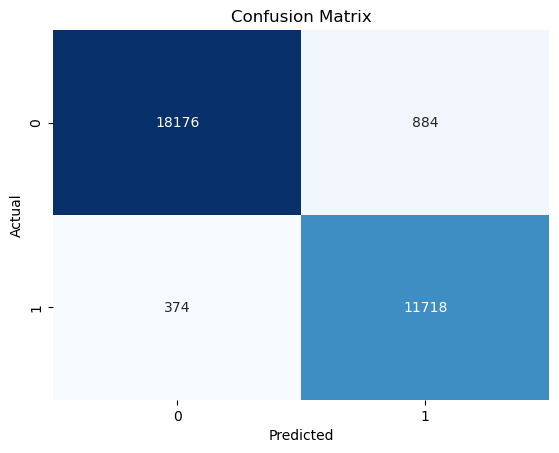

In [70]:
cm = confusion_matrix(y_test, y_predicted)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
#print(confusion_matrix(y_test, y_p))

In [71]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97     19060
           1       0.93      0.97      0.95     12092

    accuracy                           0.96     31152
   macro avg       0.95      0.96      0.96     31152
weighted avg       0.96      0.96      0.96     31152



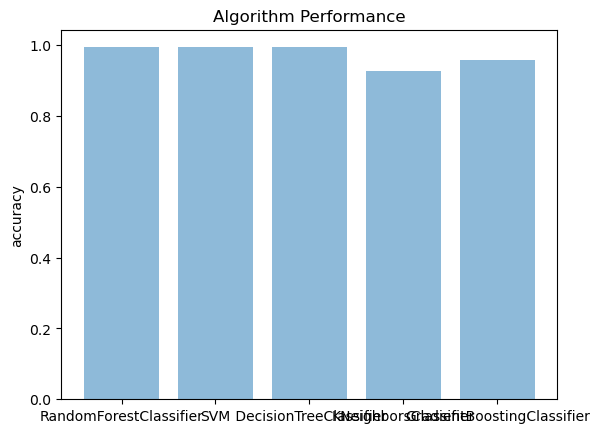

In [72]:
import matplotlib.pyplot as plt; plt.rcdefaults()
import numpy as np
import matplotlib.pyplot as plt
 
objects = ('RandomForestClassifier','SVM',' DecisionTreeClassifier','KNeighborsClassifier','GradientBoostingClassifier')
y_pos = np.arange(len(objects))
performance = [rf_acc,dt_acc,svm_acc,kn_acc,gb_acc]
 
plt.bar(y_pos, performance, align='center', alpha=0.5)
plt.xticks(y_pos, objects)
plt.ylabel('accuracy')
plt.title('Algorithm Performance')
 
plt.show()

In [73]:
import pickle
filename='ddos.sav'
pickle.dump(model ,open('ddos.sav','wb'))
loaded_model=pickle.load(open('ddos.sav','rb'))

In [74]:
pickle.dump(le ,open('encoder.pkl','wb'))
loaded_model=pickle.load(open('encoder.pkl','rb'))